In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import streamlit as st
import joblib as jb
%matplotlib inline
df = pd.read_csv(r"E:\computer science (Mostafa)\IEEE AI Task\IEEE-AI-Ambassadors-2026\Task_09\CC GENERAL.csv")
df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


## Data Exploration 

In [2]:
df.shape

(8950, 18)

In [3]:
df.ndim

2

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

In [5]:
miss = df.isnull().sum().sort_values(ascending=False)
miss_per = ((df.isnull().sum() / len(df)) * 100).round(2).sort_values(ascending=False)
pd.DataFrame({"Missing Values": miss, "Missing Percentage": miss_per})[miss > 0]

,Missing Values,Missing Percentage
MINIMUM_PAYMENTS,313,3.50
CREDIT_LIMIT,1,0.01


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
skewness = df.skew(numeric_only=True).sort_values(ascending=False)
print(skewness)

MINIMUM_PAYMENTS                    13.622797
ONEOFF_PURCHASES                    10.045083
PURCHASES                            8.144269
INSTALLMENTS_PURCHASES               7.299120
PAYMENTS                             5.907620
CASH_ADVANCE_TRX                     5.721298
CASH_ADVANCE                         5.166609
PURCHASES_TRX                        4.630655
BALANCE                              2.393386
PRC_FULL_PAYMENT                     1.942820
CASH_ADVANCE_FREQUENCY               1.828686
ONEOFF_PURCHASES_FREQUENCY           1.535613
CREDIT_LIMIT                         1.522464
PURCHASES_INSTALLMENTS_FREQUENCY     0.509201
PURCHASES_FREQUENCY                  0.060164
BALANCE_FREQUENCY                   -2.023266
TENURE                              -2.943017
dtype: float64


In [8]:
df.drop("CUST_ID", axis=1, inplace=True)


In [9]:
for i in df.columns :
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    Lower_ = Q1 - 1.5 * IQR
    Upper_ = Q3 + 1.5 * IQR
    Outlier = df[(df[i] < Lower_) | (df[i] > Upper_)]
    print("_____________________________________")
    print(f"Name of Column: {i}")
    print("Number Of Outlier : ",len(Outlier))
    print(f"Lower : {Lower_}")
    print(f"Upper : {Upper_}")
  

_____________________________________
Name of Column: BALANCE
Number Of Outlier :  695
Lower : -2760.5052645
Upper : 4942.9272155
_____________________________________
Name of Column: BALANCE_FREQUENCY
Number Of Outlier :  1493
Lower : 0.7222225000000001
Upper : 1.1666664999999998
_____________________________________
Name of Column: PURCHASES
Number Of Outlier :  808
Lower : -1566.1075000000003
Upper : 2715.8725000000004
_____________________________________
Name of Column: ONEOFF_PURCHASES
Number Of Outlier :  1013
Lower : -866.1075
Upper : 1443.5124999999998
_____________________________________
Name of Column: INSTALLMENTS_PURCHASES
Number Of Outlier :  867
Lower : -702.95625
Upper : 1171.59375
_____________________________________
Name of Column: CASH_ADVANCE
Number Of Outlier :  1030
Lower : -1670.7317088750003
Upper : 2784.5528481250003
_____________________________________
Name of Column: PURCHASES_FREQUENCY
Number Of Outlier :  0
Lower : -1.166668
Upper : 2.166668
____________

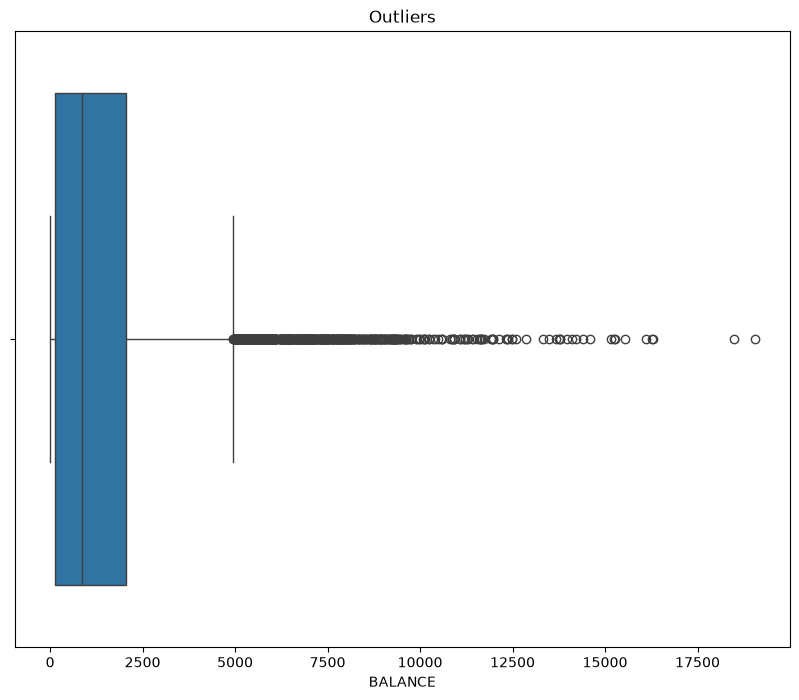

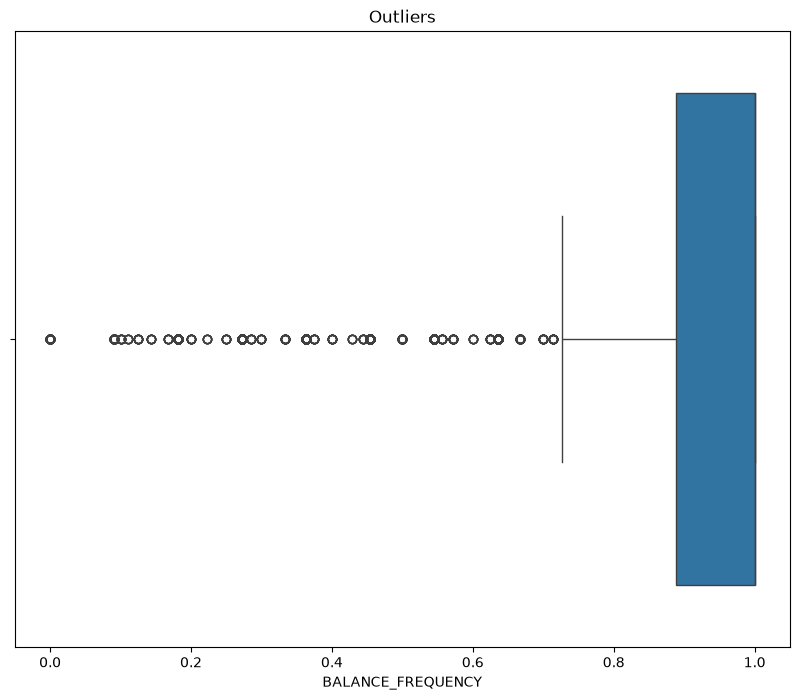

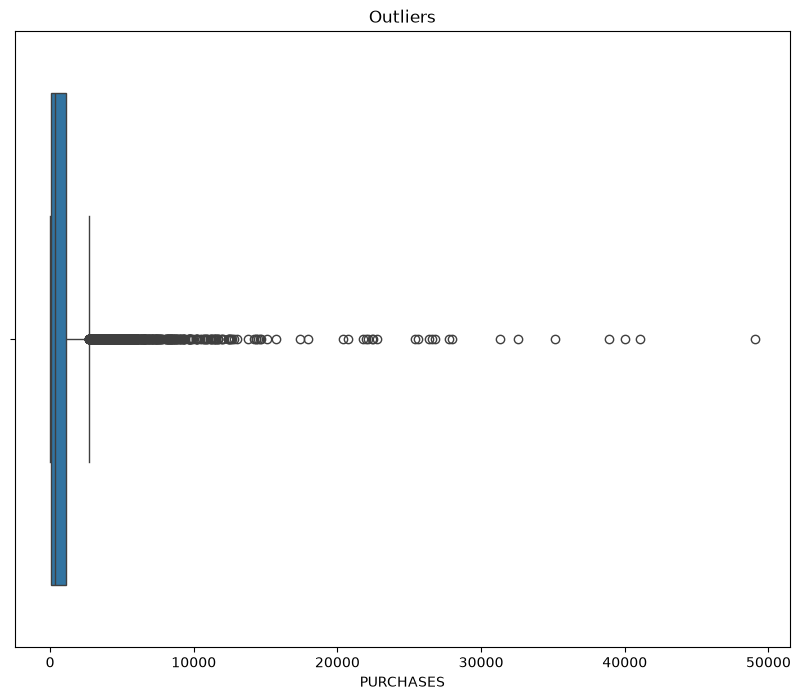

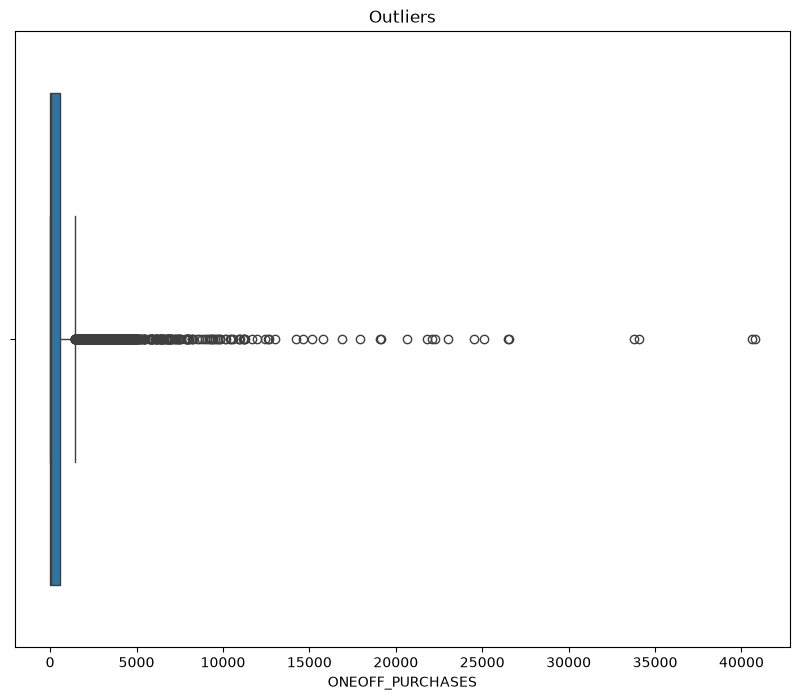

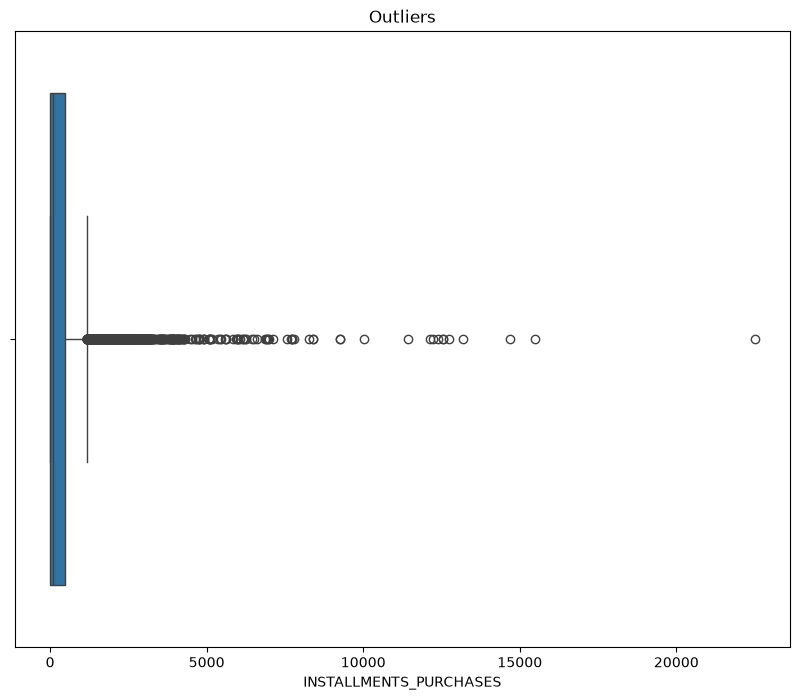

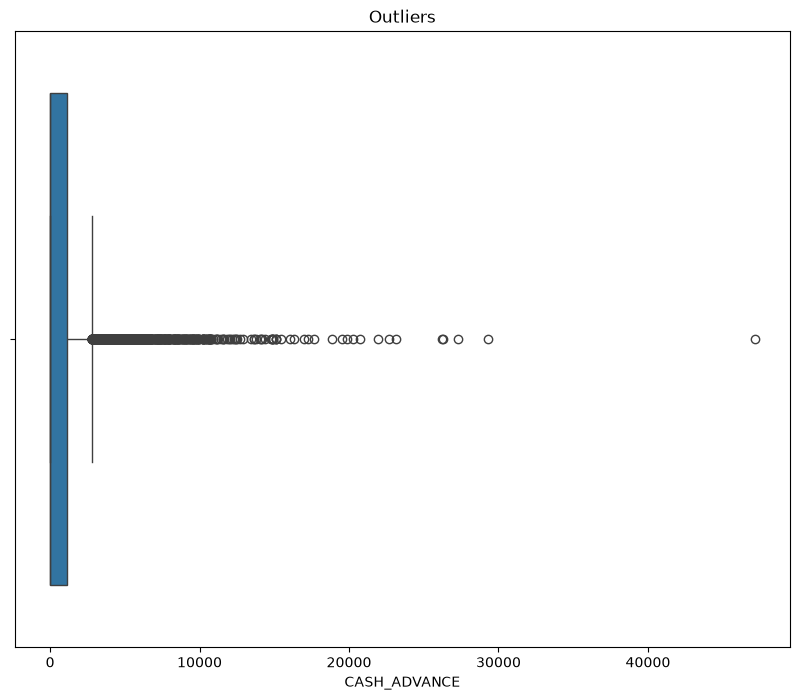

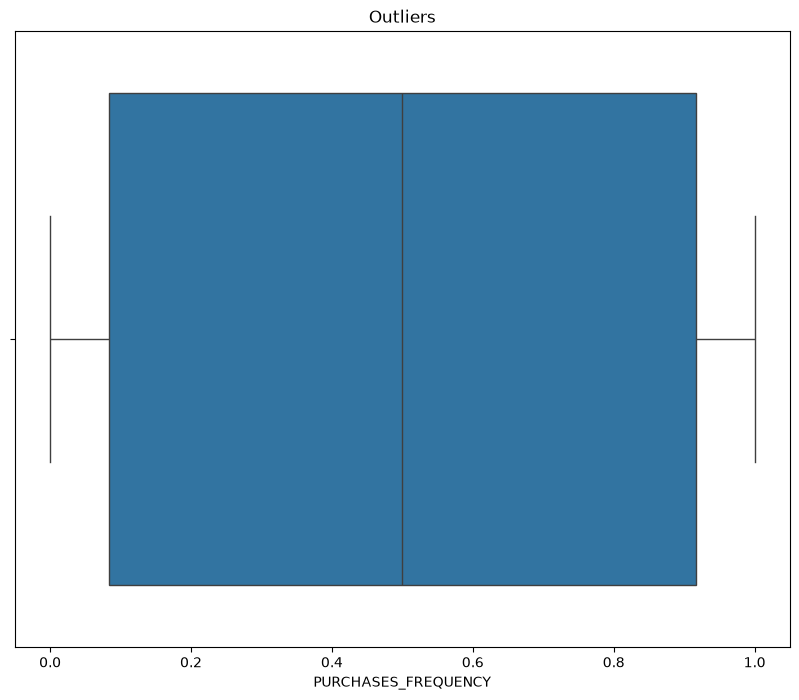

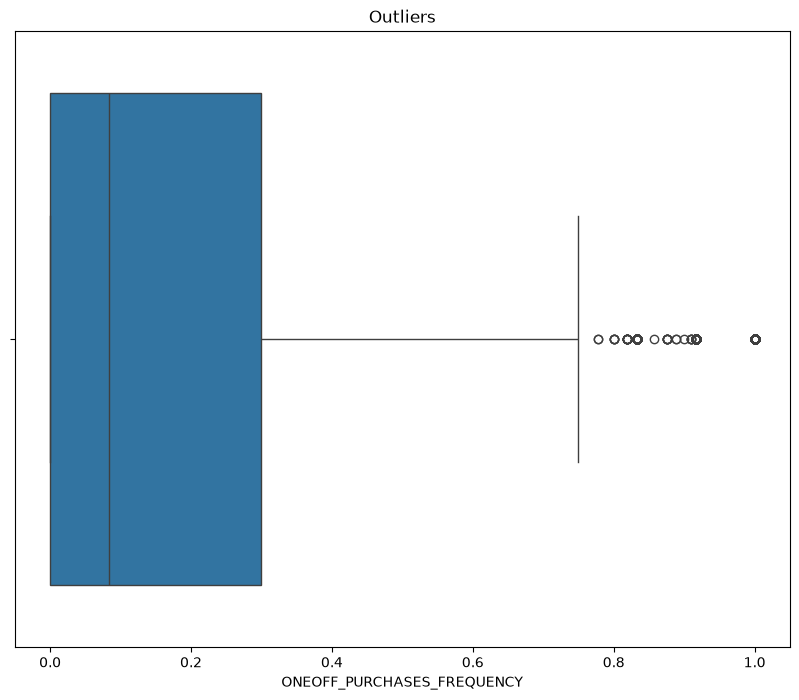

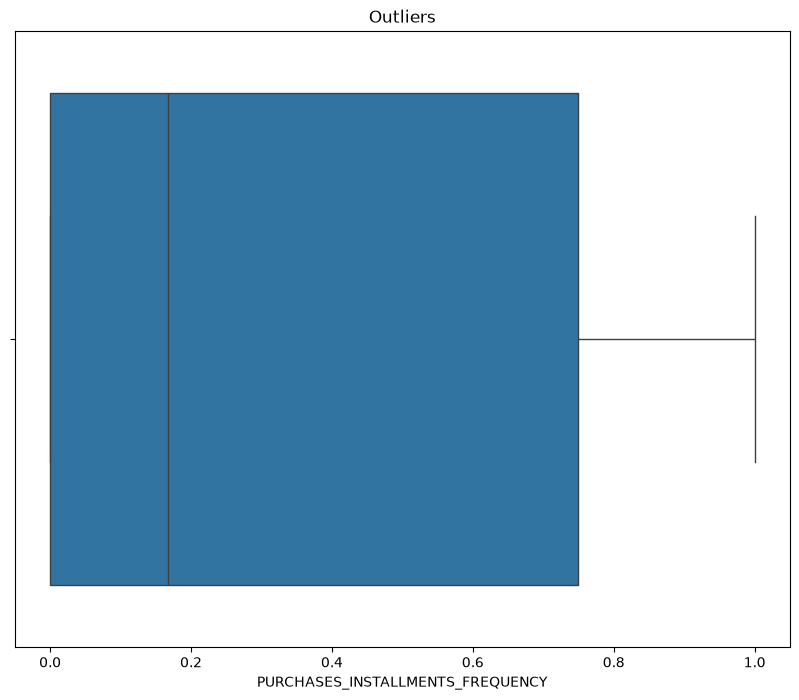

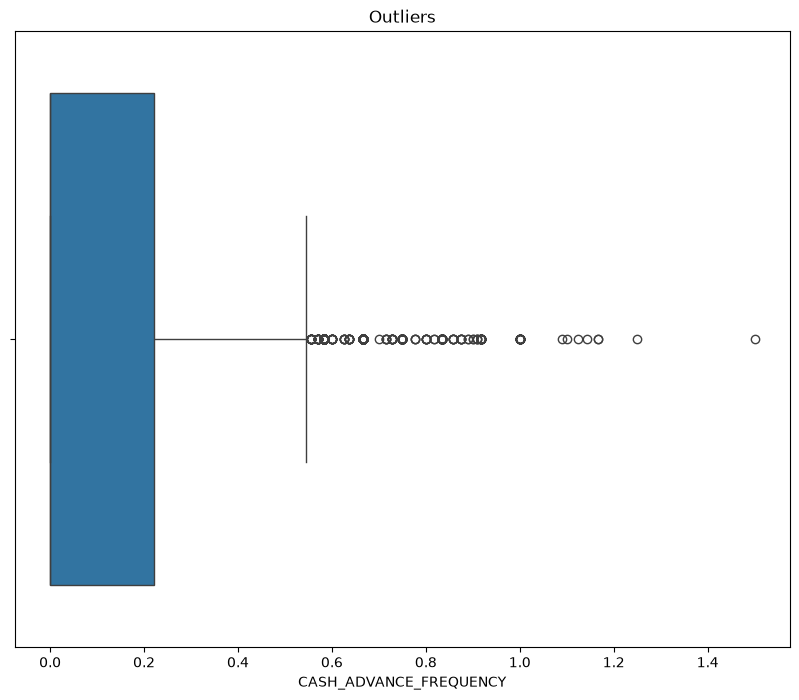

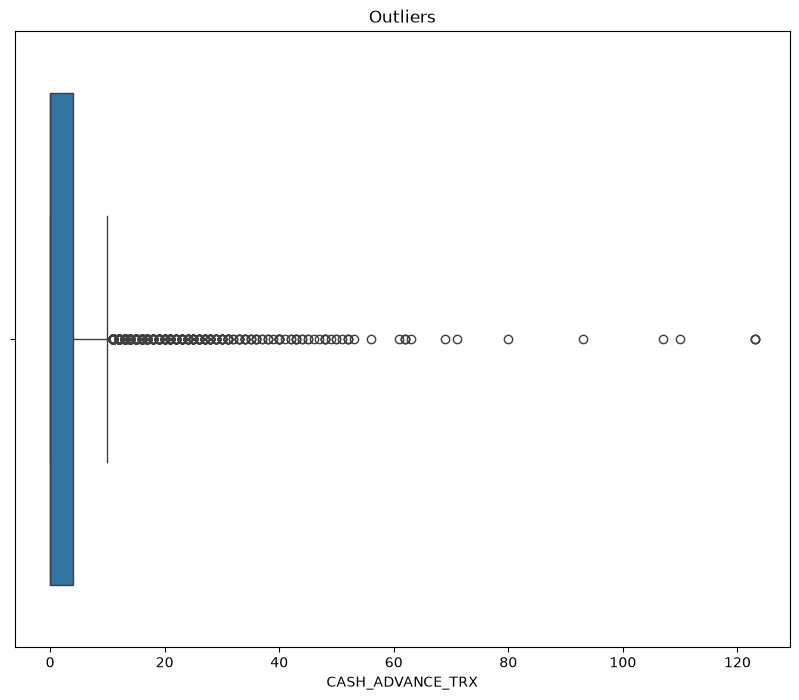

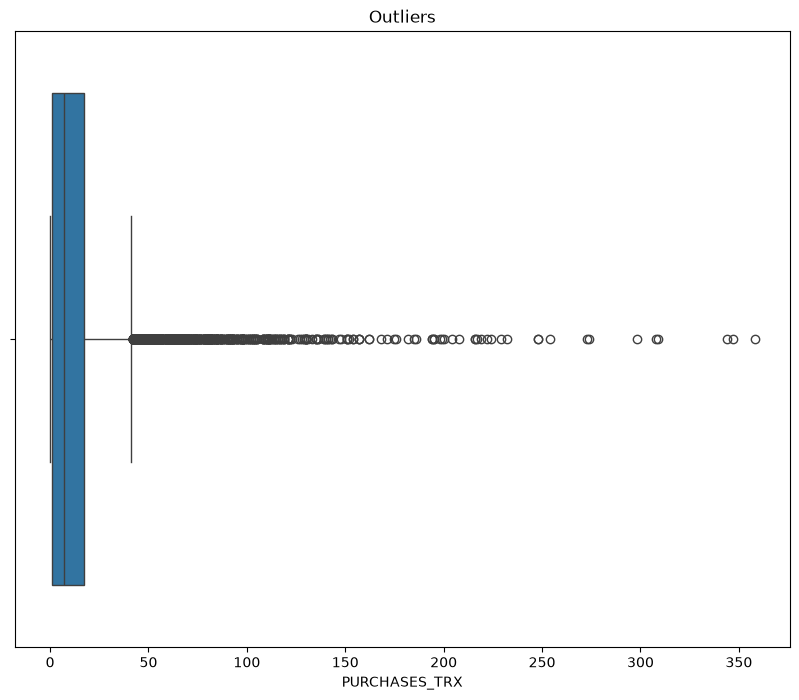

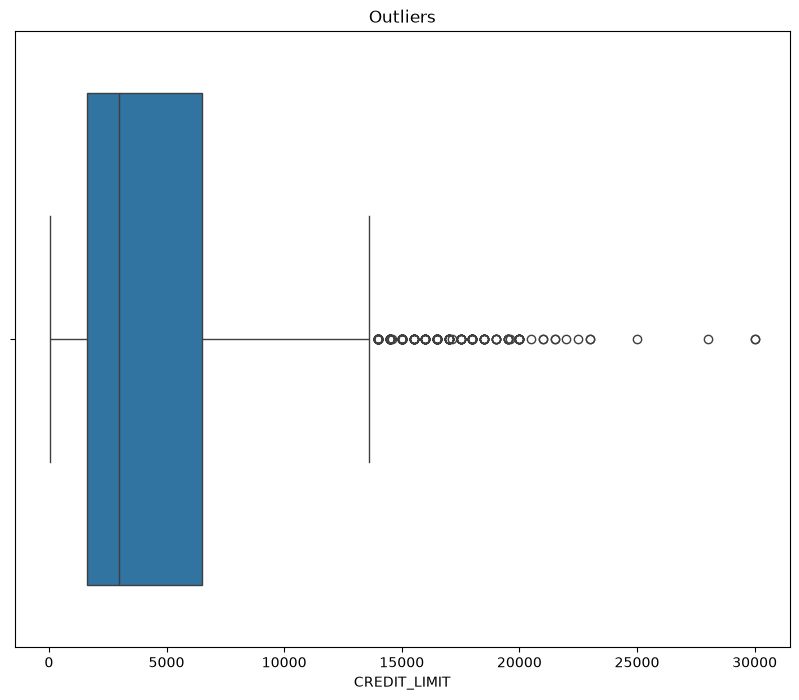

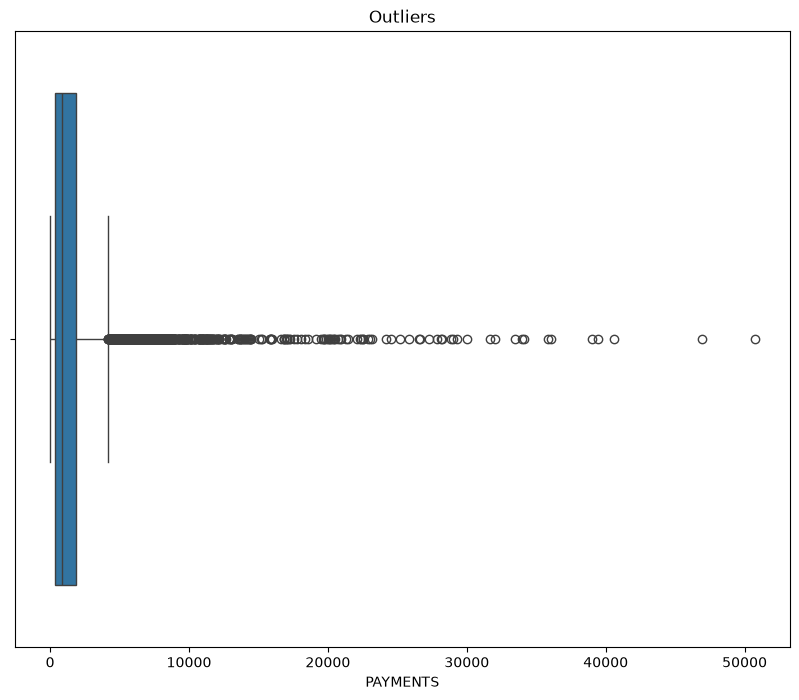

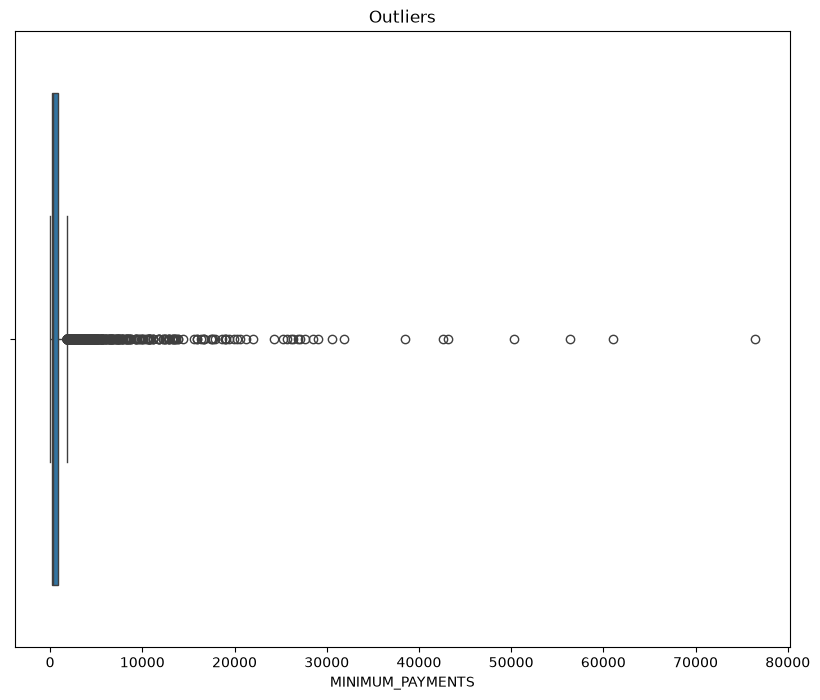

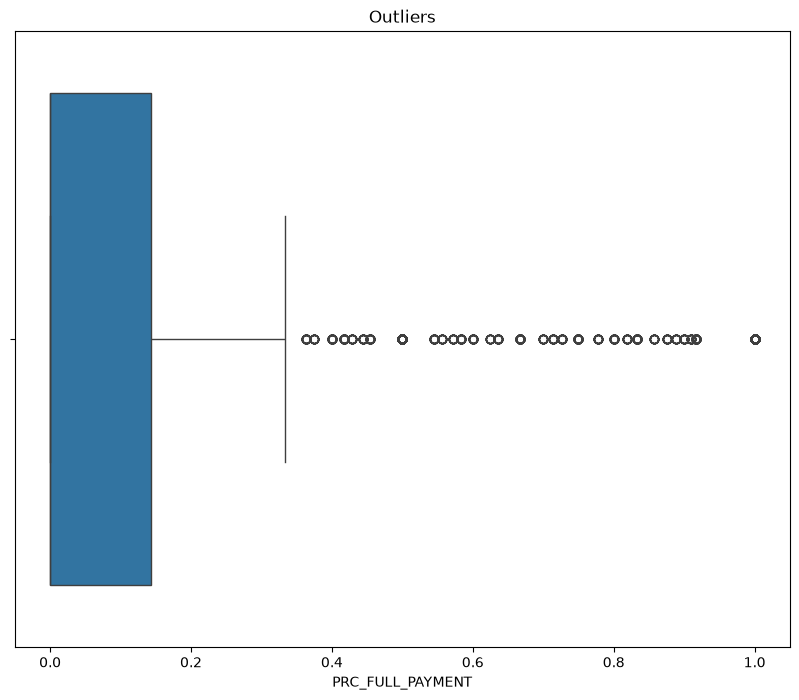

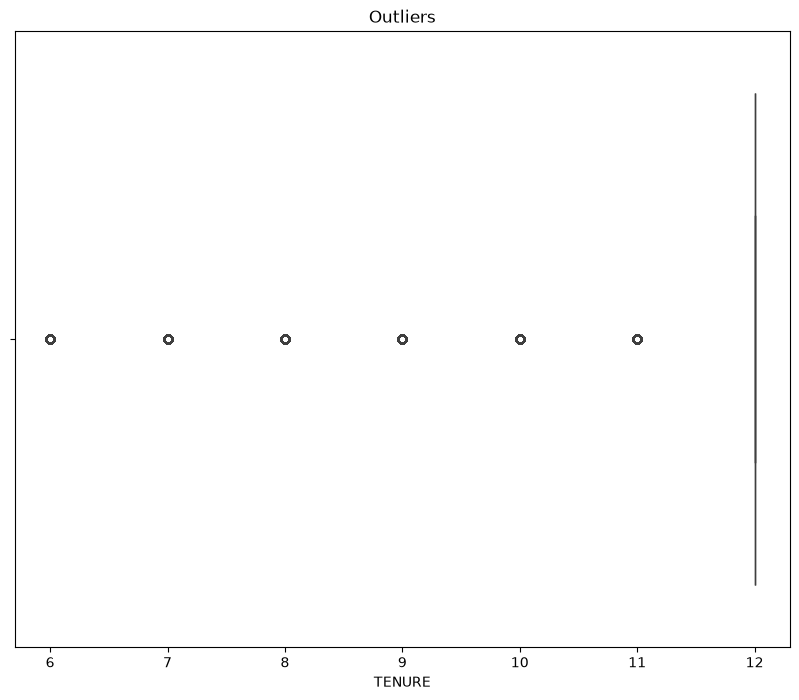

In [10]:
for i  in df.columns :
    plt.figure(figsize=(10 , 8))
    sns.boxplot(data = df ,x = i )
    plt.title(" Outliers ")
    plt.show()

## Data Spliting

In [11]:
X_train, X_test = train_test_split(df, test_size=0.2, random_state=42 )
print(X_train.shape, X_test.shape)

(7160, 17) (1790, 17)


## Fill NAN Values

In [12]:
imputer = SimpleImputer(strategy='median')

X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

## Log Transformation and  Feature Scaling  

In [13]:
X_train_log = np.log1p(X_train_imp)
X_test_log = np.log1p(X_test_imp)

In [14]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train_log)
X_test_scaled = scaler.transform(X_test_log)

In [15]:
X_train_scaled = pd.DataFrame(X_train_scaled,columns=X_train.columns,index=X_train.index)

In [16]:
X_test_scaled = pd.DataFrame(X_test_scaled,columns=X_test.columns,index=X_test.index)

In [17]:
X_train_scaled

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
7055,-0.592131,-1.825002,0.101091,0.368234,0.064417,0.000000,0.297784,1.192900,0.637357,0.000000,0.000000,0.286092,-0.130059,-1.114337,-0.564355,0.000000,-0.262364
4580,0.475219,0.000000,-1.773975,-0.564715,-0.733947,0.719181,-0.710662,-0.331903,-0.275459,0.428243,0.430677,-0.946395,0.551627,-0.041439,1.068835,0.000000,0.000000
8545,-0.178436,0.000000,-1.773975,-0.564715,-0.733947,1.218881,-0.710662,-0.331903,-0.275459,3.242949,1.543959,-0.946395,-0.783504,1.065680,0.000013,4.539279,0.000000
4463,-1.264186,-3.109313,0.501905,-0.023270,0.493793,0.000000,0.429629,0.000000,0.807670,0.000000,0.000000,0.220964,-0.289225,0.473894,-1.730049,0.000000,0.000000
5705,0.510626,0.000000,-0.571592,0.064617,-0.733947,1.129256,-0.570371,0.000000,-0.275459,1.193863,1.209062,-0.630930,0.494517,0.009211,0.903654,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5734,0.077856,0.000000,-0.112551,-0.564715,0.164202,0.000000,0.504223,-0.331903,0.963154,0.000000,0.000000,0.220964,-0.653517,-0.330115,-0.015052,0.000000,0.000000
5191,-0.014864,0.000000,-1.773975,-0.564715,-0.733947,1.034511,-0.710662,-0.331903,-0.275459,1.539156,1.365212,-0.946395,-0.130059,-0.968470,-0.060594,0.000000,0.000000
5390,-1.095945,-8.151616,-1.773975,-0.564715,-0.733947,0.970825,-0.710662,-0.331903,-0.275459,0.428243,0.682606,-0.946395,-0.494398,0.891002,-0.972696,5.190898,0.000000
860,-2.433083,-10.740054,-0.176564,-0.564715,0.129598,0.000000,0.270181,-0.331903,0.724541,0.000000,0.000000,0.286092,0.205233,-4.208319,0.000000,0.000000,0.000000


In [18]:
X_test_scaled

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
7669,-1.397347,-4.934325,-0.938748,-0.127554,-0.733947,0.761849,-0.558157,0.028897,-0.275459,0.465528,0.430677,-0.630930,0.653731,-0.427862,-0.825727,0.000000,-0.080043
6125,-0.170674,0.000000,0.159635,0.414085,0.042433,1.060617,0.184667,0.307298,0.449083,1.539156,1.489896,0.144935,-0.289225,0.405749,0.199136,0.000000,0.000000
7028,-0.711336,0.000000,-0.014742,-0.564715,0.217077,0.000000,0.504223,-0.331903,0.963154,0.000000,0.000000,0.439227,-0.289225,-0.598036,-0.409173,0.000000,0.000000
3019,0.010312,0.000000,0.500732,0.621795,-0.098183,0.760207,0.184667,1.786284,0.346945,0.428243,0.430677,0.658521,-0.494398,0.063118,-0.220458,0.000000,0.000000
3479,0.143129,0.000000,0.643874,0.620417,0.423778,0.000000,0.504223,1.112384,0.963154,0.000000,0.000000,0.765401,0.604504,1.165516,0.309992,0.599428,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1928,0.188830,0.000000,-1.773975,-0.564715,-0.733947,0.732875,-0.710662,-0.331903,-0.275459,1.539156,1.113283,-0.946395,-0.494398,-0.480182,0.330361,0.000000,0.000000
3817,0.228487,-2.271563,-1.773975,-0.564715,-0.733947,1.140292,-0.710662,-0.331903,-0.275459,0.824739,1.000000,-0.946395,0.000000,1.019687,0.313447,1.000000,0.000000
8156,-1.754359,-9.391847,-0.344591,0.183430,-0.733947,0.000000,-0.570371,0.000000,-0.275459,0.000000,0.000000,-0.446395,0.205233,-0.421263,-1.094958,0.000000,0.000000
7691,-1.399524,-0.885647,-0.217321,-0.564715,0.107565,0.000000,0.404041,-0.331903,0.637357,0.000000,0.000000,0.053605,-0.494398,-1.112658,-0.635469,2.154415,-0.262364


In [19]:
skewnesss = X_train_scaled.skew()
print(skewnesss)

BALANCE                            -0.846704
BALANCE_FREQUENCY                  -2.269948
PURCHASES                          -0.763854
ONEOFF_PURCHASES                    0.195204
INSTALLMENTS_PURCHASES             -0.027532
CASH_ADVANCE                        0.263528
PURCHASES_FREQUENCY                -0.088301
ONEOFF_PURCHASES_FREQUENCY          1.299774
PURCHASES_INSTALLMENTS_FREQUENCY    0.372627
CASH_ADVANCE_FREQUENCY              1.473712
CASH_ADVANCE_TRX                    0.955151
PURCHASES_TRX                       0.036368
CREDIT_LIMIT                       -0.116365
PAYMENTS                           -1.794389
MINIMUM_PAYMENTS                    0.274511
PRC_FULL_PAYMENT                    1.740230
TENURE                             -3.174571
dtype: float64


In [20]:
skewnessss = X_test_scaled.skew()
print(skewnessss)

BALANCE                            -0.920627
BALANCE_FREQUENCY                  -2.351632
PURCHASES                          -0.767956
ONEOFF_PURCHASES                    0.148770
INSTALLMENTS_PURCHASES             -0.015078
CASH_ADVANCE                        0.259045
PURCHASES_FREQUENCY                -0.095100
ONEOFF_PURCHASES_FREQUENCY          1.255624
PURCHASES_INSTALLMENTS_FREQUENCY    0.377865
CASH_ADVANCE_FREQUENCY              1.383053
CASH_ADVANCE_TRX                    0.878962
PURCHASES_TRX                       0.017354
CREDIT_LIMIT                       -0.041303
PAYMENTS                           -1.690524
MINIMUM_PAYMENTS                    0.254799
PRC_FULL_PAYMENT                    1.771241
TENURE                             -3.154903
dtype: float64


In [21]:
X_test_scaled.isnull().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

In [22]:
X_train_scaled.isnull().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

## Kmeans

In [23]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

train_clusters = kmeans.fit_predict(X_train_scaled)

In [24]:
X_train_clustered = X_train_scaled.copy()

X_train_clustered['Cluster'] = train_clusters

In [25]:
inertias = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)

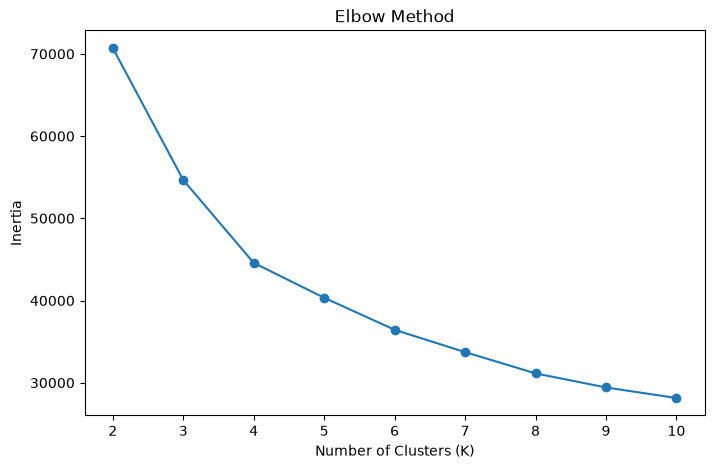

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertias, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

In [27]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_train_scaled)
    
    score = silhouette_score(X_train_scaled, labels)
    silhouette_scores.append(score)

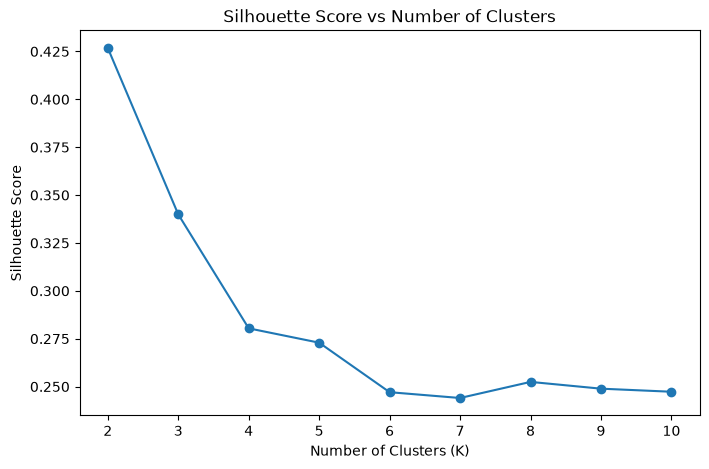

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), silhouette_scores, marker='o')

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')

plt.show()

In [29]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

train_clusters = kmeans.fit_predict(X_train_scaled)

X_train_clustered = X_train_scaled.copy()
X_train_clustered["Cluster"] = train_clusters

In [30]:
X_train_clustered["Cluster"].value_counts().sort_index()

Cluster
0    1931
1    3220
2    1070
3     939
Name: count, dtype: int64

In [31]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)

pca_df = pd.DataFrame(
    X_train_pca,
    columns=["PC1", "PC2"],
    index=X_train_scaled.index
)

pca_df["Cluster"] = train_clusters

pca_df.head()

,PC1,PC2,Cluster
7055,-0.864472,0.256075,1
4580,1.269604,-1.853223,0
8545,0.914344,0.739828,0
4463,-2.212502,0.487471,1
5705,1.536237,-1.591573,0


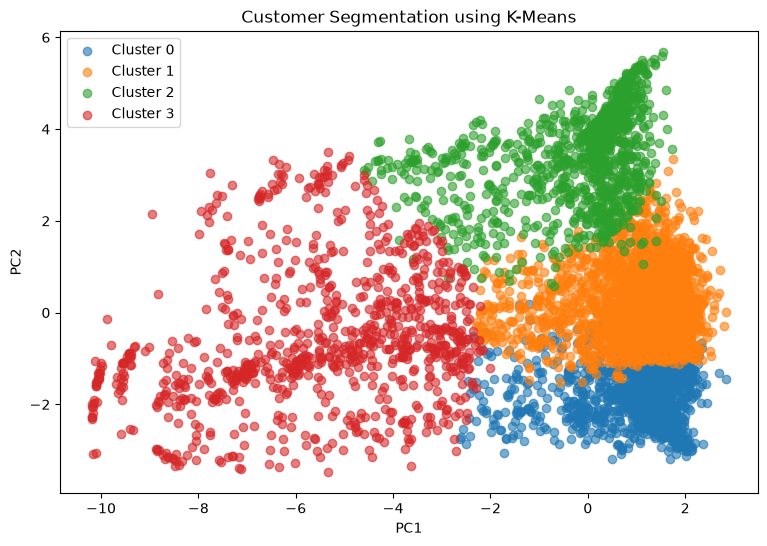

In [32]:
plt.figure(figsize=(9, 6))

for cluster in sorted(pca_df["Cluster"].unique()):
    cluster_data = pca_df[pca_df["Cluster"] == cluster]
    
    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segmentation using K-Means")
plt.legend()

plt.show()

In [33]:
cluster_profile = X_train.copy()

cluster_profile["Cluster"] = train_clusters

cluster_profile.groupby("Cluster").mean()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,2621.784547,0.964439,67.224050,48.288322,18.980756,2315.289634,0.060320,0.027915,0.029966,0.322967,8.069394,0.950803,4460.420099,1806.762999,1190.100078,0.025417,11.411704
1,1819.914054,0.971275,1430.778255,864.306102,566.714537,644.792123,0.691621,0.304310,0.512851,0.088079,2.051553,22.160870,4642.829538,1735.253574,1066.255651,0.033262,11.652484
2,198.815991,0.905701,1945.428785,1097.173243,848.283579,100.643843,0.844910,0.322732,0.658758,0.016315,0.359813,25.453271,5070.373407,2078.447829,203.905733,0.737510,11.505607
3,122.155049,0.335639,305.719606,166.702769,139.519712,429.450873,0.274252,0.064708,0.206352,0.044526,0.982961,4.381257,3672.542052,1170.498921,151.805473,0.170848,11.305644


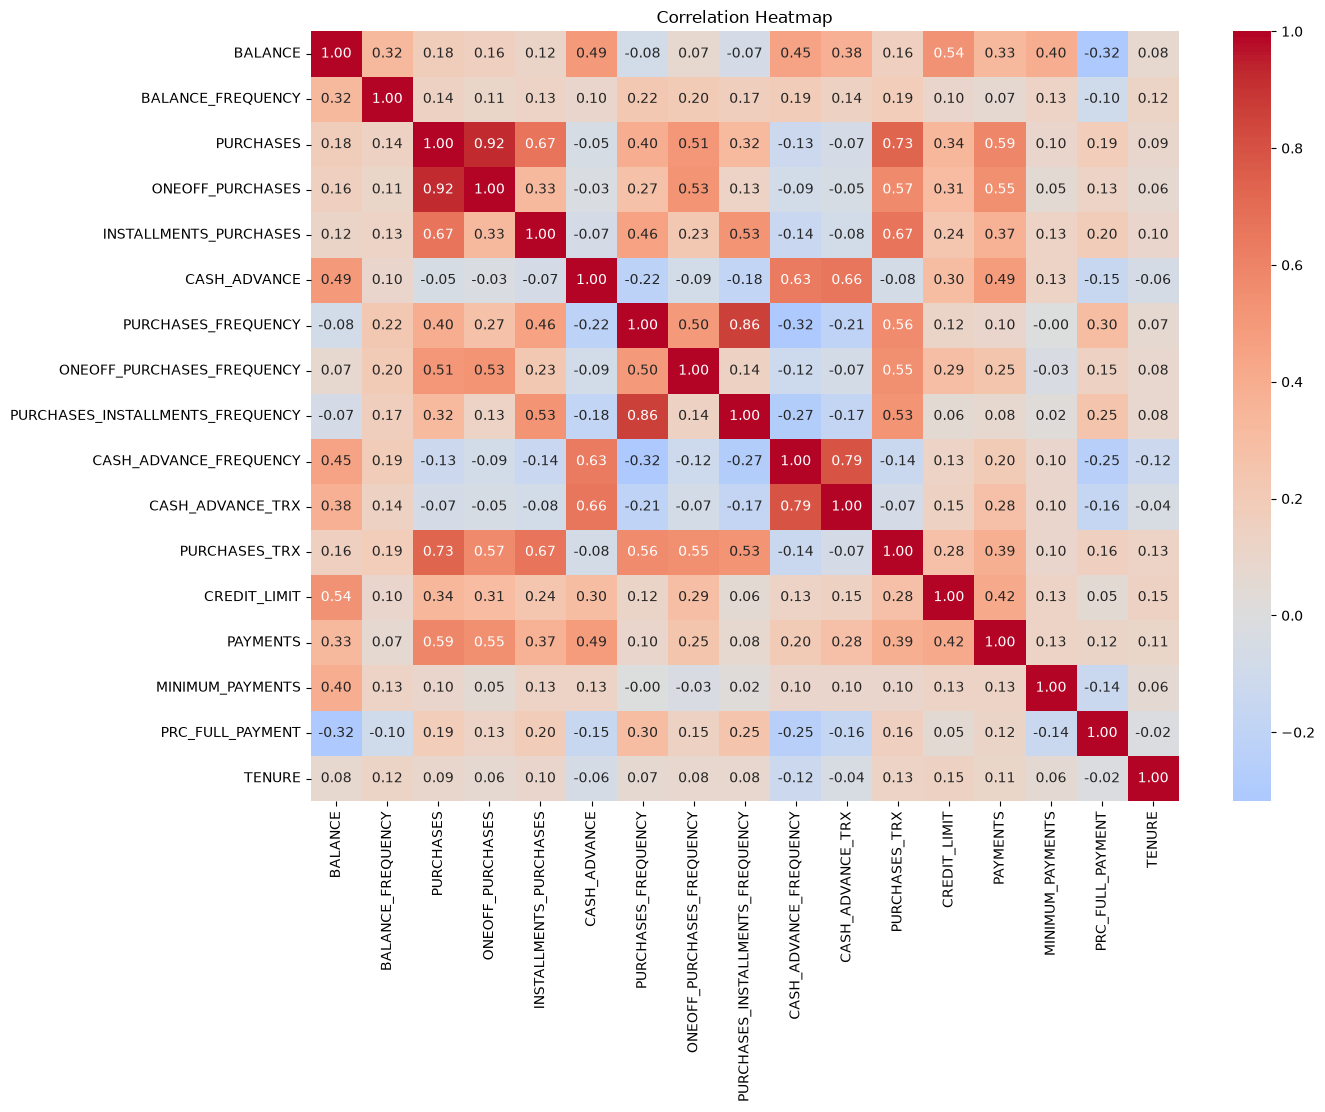

In [34]:


corr = X_train.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

In [35]:
y_train = train_clusters
y_test = kmeans.predict(X_test_scaled)

In [36]:

kmeans_final = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

y_train = kmeans_final.fit_predict(X_train_scaled)
y_test = kmeans_final.predict(X_test_scaled)

In [37]:
print(y_train.shape)
print(y_test.shape)

(7160,)
(1790,)


In [38]:
print("Train distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("Test distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Train distribution:
0    1931
1    3220
2    1070
3     939
Name: count, dtype: int64
Test distribution:
0    473
1    822
2    270
3    225
Name: count, dtype: int64


In [39]:
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

rf.fit(X_train_scaled, y_train)

rf_train_pred = rf.predict(X_train_scaled)
rf_test_pred = rf.predict(X_test_scaled)

In [40]:


print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_test_pred))

Random Forest Accuracy: 0.9815642458100559

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       473
           1       0.98      0.99      0.98       822
           2       0.97      0.98      0.97       270
           3       0.97      0.98      0.98       225

    accuracy                           0.98      1790
   macro avg       0.98      0.98      0.98      1790
weighted avg       0.98      0.98      0.98      1790



In [41]:
lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

lr_test_pred = lr.predict(X_test_scaled)

In [42]:
print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_test_pred))

print("\nClassification Report:")
print(classification_report(y_test, lr_test_pred))

Logistic Regression Accuracy: 0.9932960893854749

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       473
           1       0.99      1.00      0.99       822
           2       0.98      0.99      0.99       270
           3       1.00      0.99      0.99       225

    accuracy                           0.99      1790
   macro avg       0.99      0.99      0.99      1790
weighted avg       0.99      0.99      0.99      1790



In [43]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [44]:
rf = RandomForestClassifier()

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [45]:
grid_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose v

In [46]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [47]:
best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(X_test_scaled)

In [48]:
print("Test Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy:
0.9815642458100559

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       473
           1       0.98      0.99      0.98       822
           2       0.97      0.98      0.97       270
           3       0.98      0.98      0.98       225

    accuracy                           0.98      1790
   macro avg       0.98      0.98      0.98      1790
weighted avg       0.98      0.98      0.98      1790



In [50]:
import os

os.makedirs("models", exist_ok=True)

jb.dump(imputer, "models/imputer.pkl")
jb.dump(scaler, "models/scaler.pkl")
jb.dump(kmeans_final, "models/kmeans_model.pkl")
jb.dump(best_rf, "models/best_rf_model.pkl")
jb.dump(list(X_train.columns), "models/feature_columns.pkl")

print("All artifacts saved successfully.")

All artifacts saved successfully.
